# FBA analysis 

In [3]:
import cobra
from scipy.io import loadmat

In [4]:
tumor_path   = "/Users/valentinreateguirangel/Documents/MATLAB/MyProject/COBRA_project/cobratoolbox/tumorModel.mat"
healthy_path = "/Users/valentinreateguirangel/Documents/MATLAB/MyProject/COBRA_project/cobratoolbox/healthyModel.mat"

### Loading Tumor model 

In [6]:
# Load the MATLAB .mat model
from cobra.io import load_matlab_model

tumor_model = load_matlab_model(
    tumor_path,
    variable_name="tumorModel"   
)

### Loading Healthy model 

In [8]:
# Load the MATLAB .mat model
from cobra.io import load_matlab_model

healthy_model = load_matlab_model(
    healthy_path,
    variable_name="healthyModel"   
)

### Cheking for biomass reaction ID in both models 

In [10]:
# Tumor
# List every reaction that still has a non-zero objective coefficient
c_rxns = [r for r in tumor_model.reactions if r.objective_coefficient != 0]
print("Objective-flagged reactions:", c_rxns)
# If this prints an empty list, no objective is set.

# Search reaction *names* as well as IDs
hit = [r.id for r in tumor_model.reactions if 'biomass' in r.name.lower()]
print("Reactions whose *name* contains 'biomass':", hit)

# Healhty
# List every reaction that still has a non-zero objective coefficient
c_rxns = [r for r in healthy_model.reactions if r.objective_coefficient != 0]
print("Objective-flagged reactions:", c_rxns)
# If this prints an empty list, no objective is set.

# Search reaction *names* as well as IDs
hit = [r.id for r in healthy_model.reactions if 'biomass' in r.name.lower()]
print("Reactions whose *name* contains 'biomass':", hit)

Objective-flagged reactions: [<Reaction MAR13082 at 0x304f65370>]
Reactions whose *name* contains 'biomass': ['MAR10024', 'MAR10062', 'MAR10063', 'MAR10064', 'MAR10065', 'MAR13082']
Objective-flagged reactions: [<Reaction MAR13082 at 0x3116ec5c0>]
Reactions whose *name* contains 'biomass': ['MAR10024', 'MAR10062', 'MAR10063', 'MAR10064', 'MAR10065', 'MAR13082']


### Loading full model to extract biomass_human and push it back to the models 

In [12]:
from cobra.io import read_sbml_model

full_model = read_sbml_model("/Users/valentinreateguirangel/Downloads/Human-GEM-1.19.0/model/Human-GEM.xml")

In [13]:
# List all biomass term contained in GEM model 
biomass_rxns = [rxn for rxn in full_model.reactions 
                if 'biomass' in rxn.id.lower() or 'biomass' in rxn.name.lower()]
for rxn in biomass_rxns:
    print(rxn.id, ":", rxn.name)

MAR04413 : Generic Human Biomass Reaction
MAR09931 : Biomass maintenance reaction without replication precursors
MAR09932 : Biomass maintenance reaction without replication, transcription, and translation precursors
MAR12140 : HMR Biomass Renal Cancer Reaction
MAR10024 : Exchange of biomass
MAR10062 : Protein pool for biomass reaction
MAR10063 : Lipid pool for biomass reaction
MAR10064 : Small metabolite pool for biomass reaction
MAR10065 : Cofactors and vitamins pool for biomass reaction
MAR13082 : Generic human cell biomass reaction


In [14]:
# Biomass reaction = MAR13082
biomass_rxn = full_model.reactions.get_by_id("MAR13082")

### Precursor Extraction to map Biomass

In [16]:
# Extract precursors 
precursors = [
    met for met, coeff in biomass_rxn.metabolites.items() if coeff < 0
]

In [17]:
# Missing Biomass precursors in Tumor for MAR13082
missing = []
for met in precursors:
    try:
        tumor_model.metabolites.get_by_id(met.id)
    except KeyError:
        missing.append(met)


print(f"Biomass precursors in MAR13082: {len(precursors)}")
print(f"Missing from tumor model: {len(missing)}")

for met in missing[:10]:  
    print(f"❌ {met.id:<20} → {met.name}")

present = [met for met in precursors if met.id not in {m.id for m in missing}]
for met in present[:50]:
    print(f"✔️  {met.id:<20} → {met.name}")

Biomass precursors in MAR13082: 9
Missing from tumor model: 0
✔️  MAM01371c            → ATP
✔️  MAM01721n            → DNA
✔️  MAM02040c            → H2O
✔️  MAM02847c            → RNA
✔️  MAM03161c            → glycogen
✔️  MAM10012c            → cofactor_pool_biomass
✔️  MAM10013c            → protein_pool_biomass
✔️  MAM10014c            → lipid_pool_biomass
✔️  MAM10015c            → metabolite_pool_biomass


In [18]:
# Missing Biomass precursors in Healthy for MAR13082
missing = []
for met in precursors:
    try:
        healthy_model.metabolites.get_by_id(met.id)
    except KeyError:
        missing.append(met)


print(f"Biomass precursors in MAR13082: {len(precursors)}")
print(f"Missing from Healthy model: {len(missing)}")

for met in missing[:10]:  
    print(f"❌ {met.id:<20} → {met.name}")

present = [met for met in precursors if met.id not in {m.id for m in missing}]
for met in present[:50]:
    print(f"✔️  {met.id:<20} → {met.name}")

Biomass precursors in MAR13082: 9
Missing from Healthy model: 0
✔️  MAM01371c            → ATP
✔️  MAM01721n            → DNA
✔️  MAM02040c            → H2O
✔️  MAM02847c            → RNA
✔️  MAM03161c            → glycogen
✔️  MAM10012c            → cofactor_pool_biomass
✔️  MAM10013c            → protein_pool_biomass
✔️  MAM10014c            → lipid_pool_biomass
✔️  MAM10015c            → metabolite_pool_biomass


### Testing Biomass flux 

In [20]:
tumor_model.objective = "MAR13082"
solution = tumor_model.optimize()

if solution.status == 'optimal':
    print(f" Tumor model grows — biomass = {solution.objective_value:.4f}")
else:
    print("❌ Model still doesn’t grow ")

 Tumor model grows — biomass = 107.0296


In [22]:
tumor_model.objective = "MAR13082"
solution = healthy_model.optimize()

if solution.status == 'optimal':
    print(f" Healhty model grows — biomass = {solution.objective_value:.4f}")
else:
    print("❌ Model still doesn’t grow ")

 Healhty model grows — biomass = 107.0296


### FBA

In [24]:
"""# Activating Nutrients bakc in Python 
nutrient_bounds = {
    "MAR09034": -10,    # Glucose
    "MAR09048": -1000,  # Oxygen
    "MAR09041": -1,     # Arginine
    "MAR09047": -1,     # Lysine
    "MAR09049": -1,     # Methionine
    "MAR09043": -1,     # Phenylalanine
    "MAR09045": -1,     # Tryptophan
    "MAR09050": -1,     # Histidine
    "MAR09042": -1,     # Isoleucine
    "MAR09044": -1,     # Leucine
    "MAR09040": -1,     # Threonine
    "MAR09046": -1      # Valine
}

for rxn_id, lb in nutrient_bounds.items():
    try:
        rxn = tumor_model.reactions.get_by_id(rxn_id)
        rxn.lower_bound = lb
        rxn.upper_bound = 1000
    except KeyError:
        print(f"  {rxn_id} not found in tumor model — skipping.")

for rxn_id, lb in nutrient_bounds.items():
    try:
        rxn = healthy_model.reactions.get_by_id(rxn_id)
        rxn.lower_bound = lb
        rxn.upper_bound = 1000
    except KeyError:
        print(f"  {rxn_id} not found in healthy model — skipping.")"""

'# Activating Nutrients bakc in Python \nnutrient_bounds = {\n    "MAR09034": -10,    # Glucose\n    "MAR09048": -1000,  # Oxygen\n    "MAR09041": -1,     # Arginine\n    "MAR09047": -1,     # Lysine\n    "MAR09049": -1,     # Methionine\n    "MAR09043": -1,     # Phenylalanine\n    "MAR09045": -1,     # Tryptophan\n    "MAR09050": -1,     # Histidine\n    "MAR09042": -1,     # Isoleucine\n    "MAR09044": -1,     # Leucine\n    "MAR09040": -1,     # Threonine\n    "MAR09046": -1      # Valine\n}\n\nfor rxn_id, lb in nutrient_bounds.items():\n    try:\n        rxn = tumor_model.reactions.get_by_id(rxn_id)\n        rxn.lower_bound = lb\n        rxn.upper_bound = 1000\n    except KeyError:\n        print(f"  {rxn_id} not found in tumor model — skipping.")\n\nfor rxn_id, lb in nutrient_bounds.items():\n    try:\n        rxn = healthy_model.reactions.get_by_id(rxn_id)\n        rxn.lower_bound = lb\n        rxn.upper_bound = 1000\n    except KeyError:\n        print(f"  {rxn_id} not found in

In [25]:
# Tumor
tumor_solution = tumor_model.optimize()
print("Biomass flux =", tumor_solution.objective_value)

Biomass flux = 107.02964397587519


In [26]:
# Healhty
healthy_solution = healthy_model.optimize()
print("Biomass flux =", healthy_solution.objective_value)

Biomass flux = 107.02964397587515


## Flux Data Exploration 

In [28]:
import pandas as pd 

# Comparing fluxes
flux_df = (
    pd.DataFrame({"tumor": tumor_solution.fluxes,
                  "healthy": healthy_solution.fluxes})
      .dropna()
)
flux_df["Δ"]  = flux_df["tumor"] - flux_df["healthy"]
flux_df["|Δ|"]= flux_df["Δ"].abs()

In [29]:
# Mapping of reaction ID to reaction name 
id_to_name = {rxn.id: rxn.name for rxn in tumor_model.reactions}

# Add a new column with reaction names
flux_df["reaction_name"] = flux_df.index.map(id_to_name)

# Reorder columns to make it readable
flux_df = flux_df[["reaction_name", "tumor", "healthy", "Δ", "|Δ|"]]

# View top flux changes with names
flux_df.sort_values("|Δ|", ascending=False).head(50)

,reaction_name,tumor,healthy,Δ,|Δ|
MAR11438,Exchange of phenylpyruvate,-0.527838,1000.000000,-1000.527838,1000.527838
MAR11442,Transport of Phenylpyruvate via Proton Symport,0.527838,-1000.000000,1000.527838,1000.527838
MAR01621,"Phosphate Transport, Endoplasmic Reticulum",-0.015502,1000.000000,-1000.015502,1000.015502
MAR09033,Exchange of NEFA blood pool in,-1000.000000,0.000000,-1000.000000,1000.000000
MAR10152,"Transport of 6-Oxo-Prostaglandin F1Alpha, Lact...",-1000.000000,0.000000,-1000.000000,1000.000000
MAR05128,,0.000000,1000.000000,-1000.000000,1000.000000
MAR10219,Exchange of 6-oxo-prostaglandin F1alpha,-1000.000000,0.000000,-1000.000000,1000.000000
MAR11420,Exchange of NH4+,1000.000000,0.000000,1000.000000,1000.000000
MAR04358,ATP:pyruvate 2-O-phosphotransferase,0.000000,1000.000000,-1000.000000,1000.000000
MAR06301,,0.000000,1000.000000,-1000.000000,1000.000000


### Flux Reactions, Tumor vs Healthy

In [31]:
# Get the flux values from the solution
flux_tumor_series = tumor_solution.fluxes
flux_healthy_series = healthy_solution.fluxes

# Check absolute values against a small threshold (e.g. 1e-6) as common tolerance in metabolic modeling 
is_zero_t = flux_tumor_series.abs() < 1e-6
is_zero_h = flux_healthy_series.abs() < 1e-6

In [32]:
# Count how many are zero or nearly for Tumor flux
zero_count = is_zero_t.sum()
nonzero_count = (~is_zero_t).sum()
total_count = len(flux_tumor_series)

print(f"Total reactions in Tumor flux: {total_count}")
print(f"Zero-flux reactions Tumor flux: {zero_count}")
print(f"Active (non-zero) reactions Tumor flux: {nonzero_count}")

Total reactions in Tumor flux: 10175
Zero-flux reactions Tumor flux: 9263
Active (non-zero) reactions Tumor flux: 912


In [33]:
# Count how many are zero or nearly for Healthy flux
zero_count = is_zero_h.sum()
nonzero_count = (~is_zero_h).sum()
total_count = len(flux_healthy_series)

print(f"Total reactions in Healthy flux: {total_count}")
print(f"Zero-flux reactions Healthy flux: {zero_count}")
print(f"Active (non-zero) reactions Healthy flux: {nonzero_count}")

Total reactions in Healthy flux: 9978
Zero-flux reactions Healthy flux: 9110
Active (non-zero) reactions Healthy flux: 868


In [34]:
# Non-zero healthy reactions
active_healthy_fluxes = flux_healthy_series[~is_zero_h]

active_healthy_df = pd.DataFrame({
    "reaction_id": active_healthy_fluxes.index,
    "flux": active_healthy_fluxes.values,
    "reaction_name": [healthy_model.reactions.get_by_id(rid).name for rid in active_healthy_fluxes.index]
})

active_healthy_df["|flux|"] = active_healthy_df["flux"].abs()
active_healthy_df = active_healthy_df.sort_values(by="|flux|", ascending=False)

glucose_related_h = active_healthy_df[active_healthy_df["reaction_name"].str.lower().str.contains("gluc")]
print (glucose_related_h)

    reaction_id        flux  \
25     MAR04623  221.497675   
15     MAR04304  194.581655   
801    MAR11393  185.994940   
21     MAR04476  185.994940   
533    MAR04856   75.196632   
20     MAR04473   35.502735   
8      MAR04381   35.016296   
27     MAR08653  -26.916020   
625    MAR00090   -5.316779   
114    MAR04524    2.690939   
595    MAR09271   -2.658389   
596    MAR09272    2.658389   
624    MAR00089    2.658389   
153    MAR04767    2.658389   
792    MAR11321   -2.658389   
802    MAR11424    2.000000   
690    MAR09830   -2.000000   
115    MAR04527    0.690939   
11     MAR04128    0.455390   
691    MAR09837    0.072448   
696    MAR09864   -0.072448   

                                         reaction_name      |flux|  
25    6-Phospho-D-glucono-1,5-lactone lactonohydrolase  221.497675  
15        D-glucose-6-phosphate:NADP+ 1-oxidoreductase  194.581655  
801                        Exchange of D-gluconic acid  185.994940  
21                ATP:D-gluconate 6-phosp

In [35]:
# Non-zero tumor reactions
active_tumor_fluxes = flux_tumor_series[~is_zero_t]

active_tumor_df = pd.DataFrame({
    "reaction_id": active_tumor_fluxes.index,
    "flux": active_tumor_fluxes.values,
    "reaction_name": [tumor_model.reactions.get_by_id(rid).name for rid in active_tumor_fluxes.index]
})

active_tumor_df["|flux|"] = active_tumor_df["flux"].abs()
active_tumor_df = active_tumor_df.sort_values(by="|flux|", ascending=False)

glucose_related_t = active_tumor_df[active_tumor_df["reaction_name"].str.lower().str.contains("gluc")]
print (glucose_related_t)

    reaction_id        flux  \
6      MAR04381  357.845630   
819    MAR11393  357.188420   
23     MAR04476  357.188420   
28     MAR04625  357.157441   
703    MAR08971  357.157441   
596    MAR09685  229.257798   
845    MAR12050  229.257798   
102    MAR04628    2.690939   
8      MAR04131    0.455390   
7      MAR04396   -0.455390   
17     MAR04304    0.037606   
716    MAR09837    0.035467   
720    MAR09864   -0.035467   
27     MAR04623    0.030979   
30     MAR08653    0.006627   
714    MAR09830    0.004431   
822    MAR11424   -0.004431   

                                         reaction_name      |flux|  
6        D-glucose-6-phosphate aldose-ketose-isomerase  357.845630  
819                        Exchange of D-gluconic acid  357.188420  
23                ATP:D-gluconate 6-phosphotransferase  357.188420  
28    6-Phospho-D-glucono-1,5-lactone lactonohydrolase  357.157441  
703                  Glucose 6-Phosphate Dehydrogenase  357.157441  
596                        

## Creating a small subnetwork for each model 

### Picking a Reaction from the list 

In [142]:
target_reaction = "MAR04304"
reaction_name = "D-glucose-6-phosphate:NADP+ 1-oxidoreductase"

### Gathering Metabolites 

In [104]:
reaction = tumor_model.reactions.get_by_id(target_reaction)

In [106]:
# Split into reactants and products 
reactants =[m for m, coeff in reaction.metabolites.items() if coeff < 0] 
products  =[m for m, coeff in reaction.metabolites.items() if coeff > 0]

In [108]:
# Print reactants
print("Reactants:")
for m in reactants:
    print(f"  {m.id: <20} → {m.name}")

# Print products
print("\nProducts:")
for m in products:
    print(f"  {m.id: <20} → {m.name}")

Reactants:
  MAM01968r            → glucose-6-phosphate
  MAM02554r            → NADP+

Products:
  MAM01961r            → glucono-1,5-lactone-6-phosphate
  MAM02039r            → H+
  MAM02555r            → NADPH


In [110]:
tumor_solution.fluxes[target_reaction]

0.03760593570736321

In [130]:
healthy_solution.fluxes[target_reaction]

194.58165470695812

### Small network 

#### Healthy and Tumor 

In [182]:
import networkx as nx
import matplotlib.pyplot as plt

def draw_reaction_graph(model, solution, reaction_id, reaction_name="Target Reaction", title_prefix="Model"):
    # Get the reaction object
    reaction = model.reactions.get_by_id(reaction_id)

    # Split metabolites
    reactants = [m for m, coeff in reaction.metabolites.items() if coeff < 0]
    products  = [m for m, coeff in reaction.metabolites.items() if coeff > 0]

    # Get flux value
    flux = solution.fluxes[reaction_id]

    # Create graph
    G = nx.DiGraph()
    for m in reactants + products:
        G.add_node(m.id, label=m.name)

    for r in reactants:
        for p in products:
            G.add_edge(r.id, p.id, reaction=reaction_id, flux=flux)

    # Node colors by role
    node_colors = []
    for node in G.nodes():
        if node in [m.id for m in reactants]:
            node_colors.append("salmon")
        elif node in [m.id for m in products]:
            node_colors.append("lightgreen")
        else:
            node_colors.append("skyblue")

    # Edge labels and thickness
    labels = nx.get_node_attributes(G, 'label')
    edge_labels = {
        (u, v): f"{G[u][v]['reaction']} (flux={G[u][v]['flux']:.2f})"
        for u, v in G.edges()
    }
    edge_widths = [max(G[u][v]['flux'], 0.1) for u, v in G.edges()]

    # Draw graph
    pos = nx.spring_layout(G, seed=1)
    plt.figure(figsize=(8, 5))
    nx.draw(G, pos, labels=labels, with_labels=True, node_color=node_colors,
            node_size=2000, font_size=10, arrows=True, width=edge_widths)
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color="darkgreen")
    
    # Optional: add full reaction string
    rxn_str = reaction.reaction
    plt.title(f"{title_prefix}: {reaction_name}\n{rxn_str}", fontsize=10)
    plt.axis("off")
    plt.show()

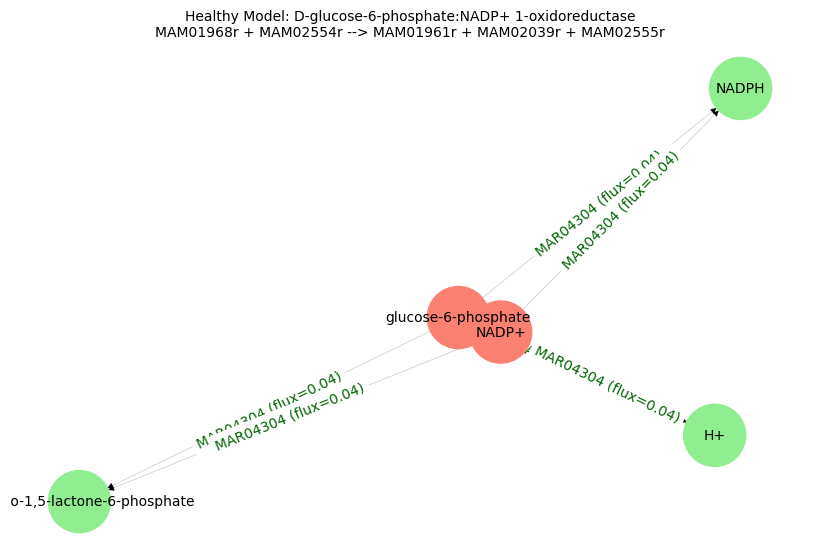

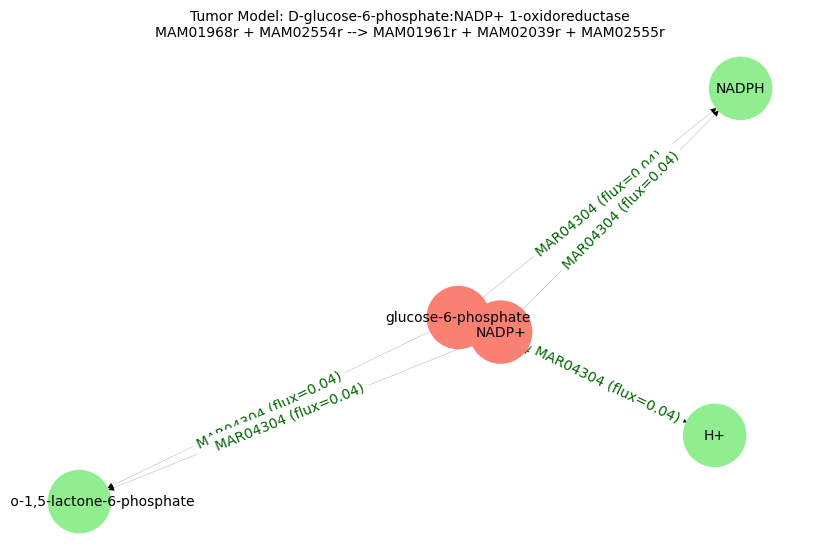

In [227]:

draw_reaction_graph(tumor_model, tumor_solution, target_reaction, reaction_name, title_prefix="Healthy Model")
draw_reaction_graph(tumor_model, tumor_solution, target_reaction, reaction_name, title_prefix="Tumor Model")

In [250]:
# Metabolic Network centered on D-glucose-6-phosphaet, includes all metabolites involve in the target reaction 
# and all 1-hop (directly connected to target reaction sharing 1 metabolite) neighbor reactions that use any of its products as reactands, Red = reactants, Green = products

import networkx as nx
import matplotlib.pyplot as plt


def draw_minimal_reaction_graph(model, solution, target_reaction_id, reaction_name="Target Reaction", title_prefix="Model"):
    target_reaction = model.reactions.get_by_id(target_reaction_id)
    G = nx.DiGraph()
    seen_reactions = set([target_reaction_id])

    def add_reaction(reaction):
        flux = solution.fluxes.get(reaction.id, 0.0)
        reactants = [m for m, c in reaction.metabolites.items() if c < 0]
        products  = [m for m, c in reaction.metabolites.items() if c > 0]
        for m in reactants + products:
            G.add_node(m.id, label=m.name)
        for r in reactants:
            for p in products:
                G.add_edge(r.id, p.id, flux=flux)

    # Add main reaction
    add_reaction(target_reaction)

    # Add neighbors (1 hop)
    target_products = [m for m, c in target_reaction.metabolites.items() if c > 0]
    for m in target_products:
        for rxn in model.reactions:
            if rxn.id not in seen_reactions and m in rxn.reactants:
                add_reaction(rxn)
                seen_reactions.add(rxn.id)

    # Layout and visual setup
    pos = nx.spring_layout(G, seed=1)
    edge_widths = [min(5, max(abs(G[u][v]["flux"]), 0.1)) for u, v in G.edges()]
    node_colors = []
    all_reactants = [m for r in seen_reactions for m in model.reactions.get_by_id(r).reactants]
    all_products = [m for r in seen_reactions for m in model.reactions.get_by_id(r).products]

    for node in G.nodes():
        if node in [m.id for m in all_reactants]:
            node_colors.append("salmon")
        elif node in [m.id for m in all_products]:
            node_colors.append("lightgreen")
        else:
            node_colors.append("grey")

    # Optional: show tiny or no labels
    labels = nx.get_node_attributes(G, "label")
    labels = {k: v[:10] for k, v in labels.items()}  # shorten

    # Draw minimalist plot
    plt.figure(figsize=(12, 8))
    nx.draw(
        G, pos,
        node_color=node_colors,
        node_size=20,  # very small dots
        arrows=True,
        width=edge_widths,
        with_labels=False
    )

    plt.title(f"{title_prefix}: {reaction_name}\n{target_reaction.reaction}", fontsize=10)
    plt.axis("off")
    plt.show()

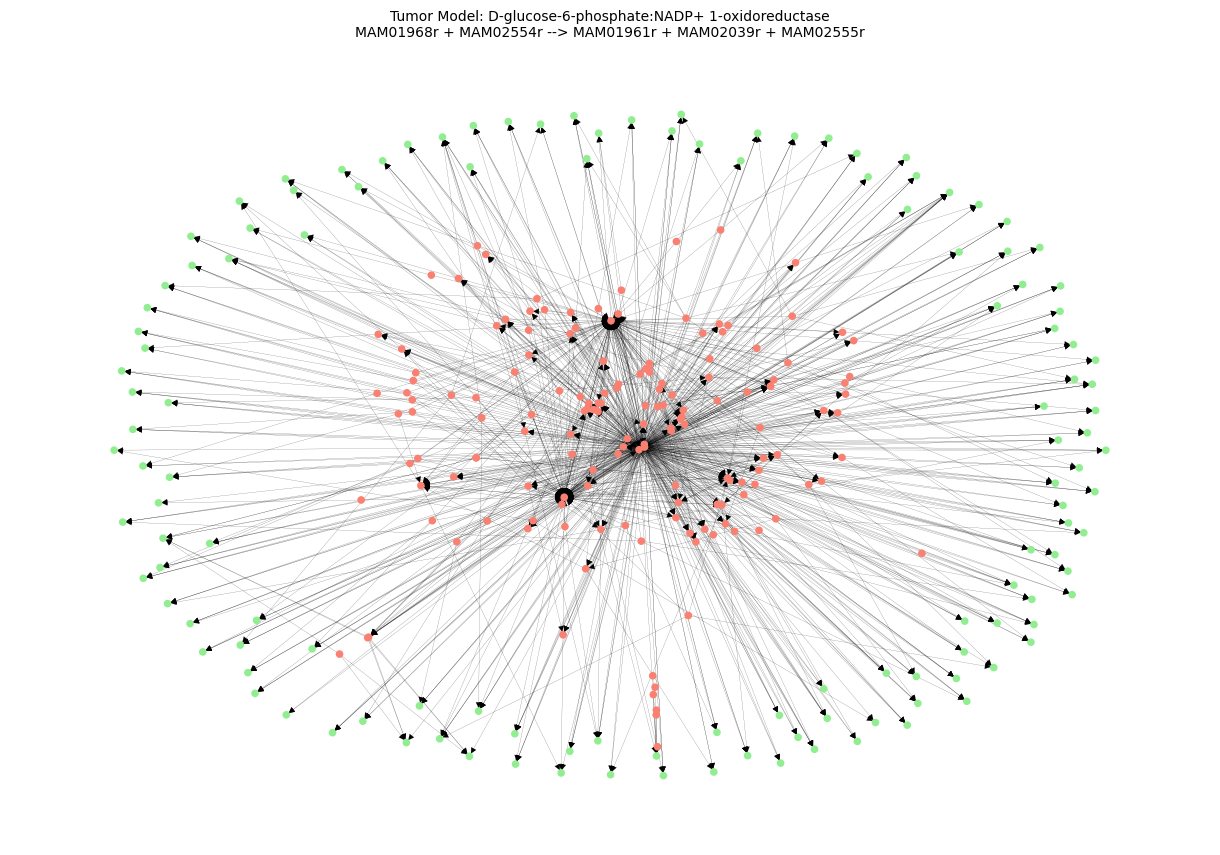

In [253]:
# Tumor Model
draw_minimal_reaction_graph(
    tumor_model,
    tumor_solution,
    target_reaction,
    reaction_name,
    title_prefix="Tumor Model"
)

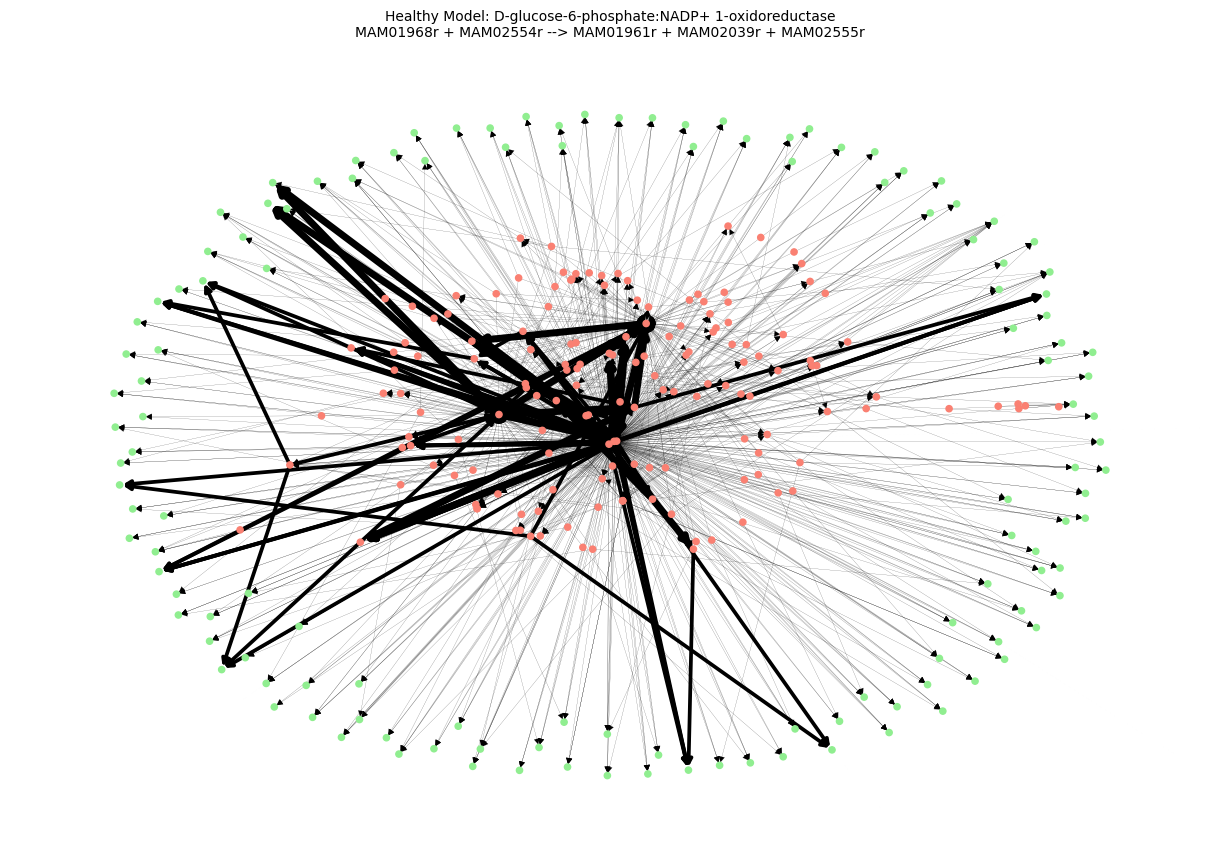

In [255]:
# Healthy Model
draw_minimal_reaction_graph(
    healthy_model,
    healthy_solution,
    target_reaction,
    reaction_name,
    title_prefix="Healthy Model"
)

In [241]:
# pyvis model 
from pyvis.network import Network
net = Network(height="700px", width="100%", notebook=True)

# Add nodes/edges
for node in G.nodes():
    label = G.nodes[node]['label']
    net.add_node(node, label=label, title=label)

for u, v in G.edges():
    flux = G[u][v]['flux']
    net.add_edge(u, v, title=f"Flux: {flux:.2f}", value=abs(flux))

net.show("reaction_network.html")

reaction_network.html
